# Logistic Regression




Logistic Regression: A classification technique that models the probability of a categorical dependent variable (e.g., binary outcomes) based on one or more independent variables, using the logistic function.



### **Logistic regression** is a classification algorithm used to model the probability of a binary outcome based on one or more predictor variables.
- It finds the relationship between qualitative variables and independent variables.
- It is a machine learning method used to distinguish one class from another.
- The main goal of logistic regression is to accurately predict the class of the two possible label data points.
- A logistic regression model ensures that the output always falls between 0 and 1, as used in the sigmoid function.


![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/New/Lesson_04_Supervised_Learning_Regression/logistic_regression.png)

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/New/Lesson_04_Supervised_Learning_Regression/log_reg_formula.png)

If you plot this formula on a chart, you get the below image:

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/New/Lesson_04_Supervised_Learning_Regression/sigmoid_function.png)

- It maps predictions to probabilities.
- It maps any real value to the other value between 0 and 1.

# Logistic Regression

# Let’s consider a football scenario: as a player moves further from the goalpost, the chance of scoring decreases — but not linearly."
# "We’re trying to predict whether the player scores or not — a binary outcome, not a continuous value."
# "Linear regression will try to fit a straight line, which might predict probabilities like 1.2 or -0.3 — clearly invalid."
# "This is where logistic regression shines — it models the probability of the outcome using a sigmoid function."


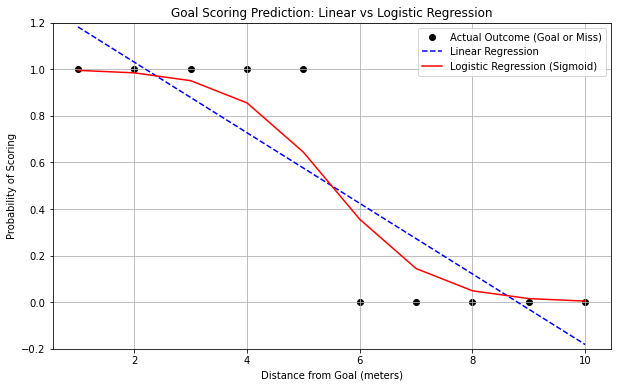

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

# Distance from goal in meters
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
# 1 = Goal scored, 0 = Missed
y = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

# Fit Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)

# Fit Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X, y)
y_pred_log = log_reg.predict_proba(X)[:, 1]  # Probability of scoring

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Outcome (Goal or Miss)')
plt.plot(X, y_pred_lin, label='Linear Regression', linestyle='--', color='blue')
plt.plot(X, y_pred_log, label='Logistic Regression (Sigmoid)', color='red')
plt.title('Goal Scoring Prediction: Linear vs Logistic Regression')
plt.xlabel('Distance from Goal (meters)')
plt.ylabel('Probability of Scoring')
plt.legend()
plt.grid(True)
plt.ylim(-0.2, 1.2)
plt.show()


"Notice how the linear model cuts across the data but doesn’t respect the 0–1 probability bounds."
"The logistic regression curve, on the other hand, gracefully transitions from high to low probability — just as we’d expect in reality."
"This curve tells us: when you're close to the goal, the model is confident you'll score; as you move away, that confidence drops."

In [ ]:
# visualization of the plots

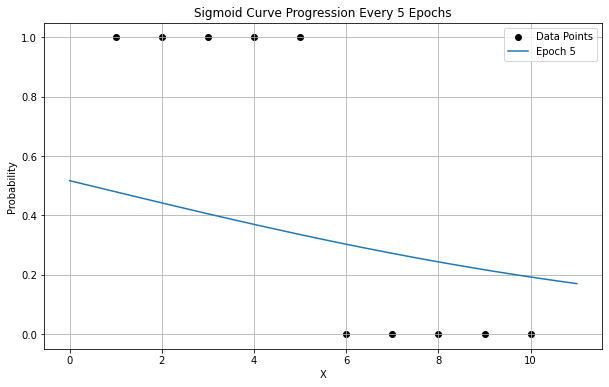

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
# 1 = Goal scored, 0 = Missed
y = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Add intercept term

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradient descent for logistic regression
def logistic_gradient_descent(X_b, y, lr=0.1, epochs=100):
    weights = np.zeros(X_b.shape[1])
    history = []

    for epoch in range(1, epochs + 1):
        z = np.dot(X_b, weights)
        y_pred = sigmoid(z)
        error = y_pred - y
        gradient = (1 / len(y)) * np.dot(X_b.T, error)
        weights -= lr * gradient

        if epoch % 5 == 0:
            history.append((epoch, weights.copy()))

    return history

# Train and collect weights every 5 epochs
history = logistic_gradient_descent(X_b, y, lr=0.1, epochs=5)

# Plot
x_range = np.linspace(0, 11, 100)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y, color='black', label="Data Points")

for epoch, weights in history:
    z_vals = weights[0] + weights[1] * x_range
    y_vals = sigmoid(z_vals)
    ax.plot(x_range, y_vals, label=f"Epoch {epoch}")

ax.set_title("Sigmoid Curve Progression Every 5 Epochs")
ax.set_xlabel("X")
ax.set_ylabel("Probability")
ax.legend()
ax.grid(True)
plt.show()


# lets built Logistic from Scratch

In [ ]:
# An example from scratch

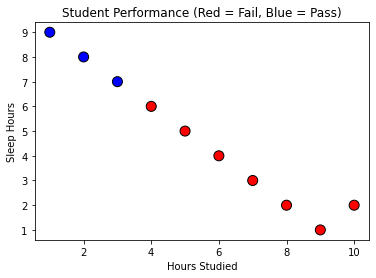

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic dataset
np.random.seed(42)
X = np.array([
    [2, 8], [3, 7], [5, 5], [1, 9], [4, 6], [7, 3], [8, 2], [6, 4], [9, 1], [10, 2]
])
y = np.array([0, 0, 1, 0, 1, 1, 1, 1, 1, 1])  # 1 = Pass, 0 = Fail

# Visualizing the data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=100)
plt.xlabel("Hours Studied")
plt.ylabel("Sleep Hours")
plt.title("Student Performance (Red = Fail, Blue = Pass)")
plt.show()


In [ ]:
# building from scratch

In [ ]:
import numpy as np

# Sigmoid activation function: maps any real number to a value between 0 and 1
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Binary cross-entropy loss function:
# Measures how well predicted probabilities match the true labels (y)
def compute_loss(y, y_pred):
    m = len(y)  # Number of data points
    # Adding a small value (1e-8) for numerical stability to avoid log(0)
    return - (1/m) * np.sum(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))

# So when we minimize this loss,
# we are maximizing the likelihood — this is maximum likelihood estimation in action.



# Gradient Descent for Logistic Regression with verbose output
def gradient_descent_verbose(X, y, lr=0.1, epochs=1000):
    m, n = X.shape  # m = number of samples, n = number of features
    weights = np.zeros(n)  # Initialize weights to zero
    bias = 0  # Initialize bias to zero

    # Repeat optimization for a fixed number of epochs
    for epoch in range(epochs):
        # Linear combination of inputs and weights plus bias: z = X·w + b
        linear_model = np.dot(X, weights) + bias

        # Apply sigmoid to get predicted probabilities (ŷ)
        y_pred = sigmoid(linear_model)

        # Gradient of loss w.r.t. weights
        dw = (1/m) * np.dot(X.T, (y_pred - y))
        # Gradient of loss w.r.t. bias
        db = (1/m) * np.sum(y_pred - y)

        # Print internal values for understanding, every 100 epochs or on first epoch
        if epoch % 100 == 0 or epoch == 0:
            loss = compute_loss(y, y_pred)  # Calculate current loss
#             It's used only for monitoring how well the model is performing (printed every few epochs).
#             It is not required to compute the gradients directly
            print(f"\n--- Epoch {epoch} ---")
            print(f"Linear output (z):\n{linear_model}")  # Show z = X·w + b
            print(f"Predicted probabilities (ŷ):\n{y_pred}")  # Probabilities from sigmoid
            print(f"Loss: {loss:.4f}")  # Show loss
            print(f"Gradient w.r.t weights (dw):\n{dw}")  # Gradient for weights
            print(f"Gradient w.r.t bias (db): {db}")  # Gradient for bias
            print(f"Weights before update:\n{weights}")  # Before update
            print(f"Bias before update: {bias}")  # Before update

        # Update weights and bias using gradient descent step
        weights -= lr * dw  # Move in direction that reduces the loss
        bias -= lr * db

        # Show updated weights and bias every 100 epochs
        if epoch % 100 == 0 or epoch == 0:
            print(f"Weights after update:\n{weights}")
            print(f"Bias after update: {bias}")

    # Return the learned model parameters
    return weights, bias

# Predict class labels using trained weights and bias
def predict(X, weights, bias):
    # Compute predicted probabilities
    y_pred = sigmoid(np.dot(X, weights) + bias)
    # Convert probabilities to 0 or 1 using a threshold of 0.5
    return [1 if i > 0.5 else 0 for i in y_pred]


X = np.array([
    [2, 8], [3, 7], [5, 5], [1, 9], [4, 6], [7, 3], [8, 2], [6, 4], [9, 1], [10, 2]
])
y = np.array([0, 0, 1, 0, 1, 1, 1, 1, 1, 1])  # 1 = Pass, 0 = Fail


# Train the logistic regression model
weights, bias = gradient_descent_verbose(X, y, lr=0.1, epochs=1000)

# Use the trained model to predict on the training data
y_pred = predict(X, weights, bias)

# Evaluate the model by calculating accuracy (correct predictions / total)
accuracy = np.mean(y == y_pred)
print(f"\nFinal Accuracy: {accuracy:.4f}")



--- Epoch 0 ---
Linear output (z):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicted probabilities (ŷ):
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Loss: 0.6931
Gradient w.r.t weights (dw):
[-2.15  0.05]
Gradient w.r.t bias (db): -0.2
Weights before update:
[0. 0.]
Bias before update: 0
Weights after update:
[ 0.215 -0.005]
Bias after update: 0.020000000000000004

--- Epoch 100 ---
Linear output (z):
[-3.18088904 -1.09087361  3.08915724 -5.27090447  0.99914182  7.2691881
  9.35920353  5.17917267 11.44921896 12.05529075]
Predicted probabilities (ŷ):
[0.03989127 0.25145381 0.95644327 0.00511269 0.73088982 0.99930381
 0.99991384 0.99439888 0.99998934 0.99999419]
Loss: 0.0700
Gradient w.r.t weights (dw):
[-0.04942911  0.02681886]
Gradient w.r.t bias (db): -0.0022609091694368367
Weights before update:
[ 1.34804361 -0.74197182]
Bias before update: 0.05879827310478187
Weights after update:
[ 1.35298652 -0.7446537 ]
Bias after update: 0.059024364021725555

--- Epoch 200 ---
Linear output (z):
[-4.07444

In [ ]:
# Custom prediction probabilities
z_custom = np.dot(X, weights) + bias
custom_probs = sigmoid(z_custom)
print("🔧 Custom Model Probabilities:\n", custom_probs)

🔧 Custom Model Probabilities:
 [7.67379396e-04 8.23639547e-02 9.99185047e-01 6.57078839e-06
 9.12970439e-01 9.99999940e-01 9.99999999e-01 9.99993022e-01
 1.00000000e+00 1.00000000e+00]


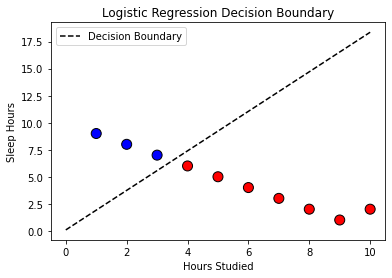

In [ ]:
# Plot decision boundary
import matplotlib.pyplot as plt
x1 = np.linspace(0, 10, 100)
x2 = -(weights[0] * x1 + bias) / weights[1]  # Decision boundary formula

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=100)
plt.plot(x1, x2, color='black', linestyle='--', label="Decision Boundary")
plt.xlabel("Hours Studied")
plt.ylabel("Sleep Hours")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

In [ ]:
# Using Inbuilt function

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

model = LogisticRegression(penalty=None) # without using optimized solvers
model.fit(X, y)

# Predict
y_pred = model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))
print("Classification Report:\n", classification_report(y, y_pred))

probs = model.predict_proba(X)
print("Prediction Probabilities:\n", probs)

inbuilt_probs = model.predict_proba(X)[:, 1]  # Get P(class=1)


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Prediction Probabilities:
 [[1.00000000e+00 1.53713825e-11]
 [9.99728680e-01 2.71319542e-04]
 [1.18203225e-11 1.00000000e+00]
 [1.00000000e+00 8.70616587e-19]
 [2.08652915e-04 9.99791347e-01]
 [0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 1.00000000e+00]]


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Custom Prob": np.round(custom_probs,4),
    "Inbuilt Prob": np.round(inbuilt_probs,4)
})
print("\n📊 Probability Comparison:\n", comparison)


📊 Probability Comparison:
    Custom Prob  Inbuilt Prob
0       0.0008        0.0000
1       0.0824        0.0003
2       0.9992        1.0000
3       0.0000        0.0000
4       0.9130        0.9998
5       1.0000        1.0000
6       1.0000        1.0000
7       1.0000        1.0000
8       1.0000        1.0000
9       1.0000        1.0000



Logistic Regression:
Accuracy: 0.8
Confusion Matrix:
[[14  5]
 [ 3 18]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        19
           1       0.78      0.86      0.82        21

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40

Log Loss: 0.36936534716977454


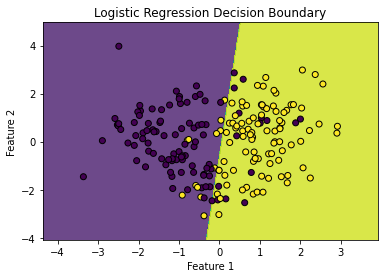

In [ ]:
# Logistic Regression -> linear in logit

# = log(T(x)/1-(T(x))) = log of success/ failure = logit

# Generate sample data for logistic regression
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, random_state=42)
# print(X,y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Logistic Regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

# Predict on test data
y_pred = logistic_model.predict(X_test)

# Evaluate the model
print("\nLogistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

from sklearn.metrics import log_loss

# Predict probabilities (not just labels)
y_pred_prob = logistic_model.predict_proba(X_test)
# print('log loss',y_pred_prob)
print(f"Log Loss: {log_loss(y_test, y_pred_prob)}")


# Plot the decision boundary
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', marker='o')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Logistic Regression Decision Boundary')
    plt.show()

plot_decision_boundary(logistic_model, X, y)

In [ ]:
 # Some example for you to think through

714
Titanic Dataset - Classification Report
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       126
           1       0.72      0.70      0.71        89

    accuracy                           0.76       215
   macro avg       0.76      0.75      0.75       215
weighted avg       0.76      0.76      0.76       215



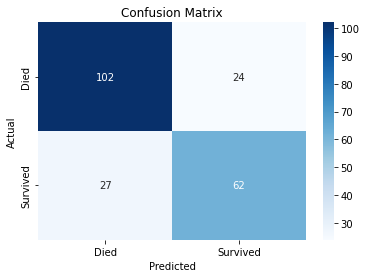

Diagonal cells (TN and TP) are correct predictions
Off-diagonal cells (FP and FN) are errors
It gives a quick sense of how many passengers were misclassified and in what way


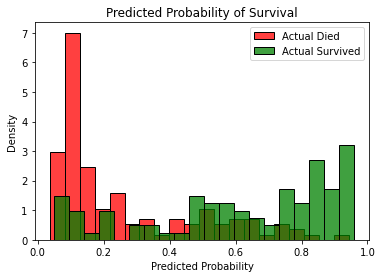

Here you see something like “5% of the distribution is in the 0.8–0.9 range
Red bars show the distribution of predicted survival probabilities for passengers who actually died
Green bars show the same, but for passengers who actually survived
We are not just counting how many — we are showing the shape of the model’s confidence, normalized to be on the same scale for both classes


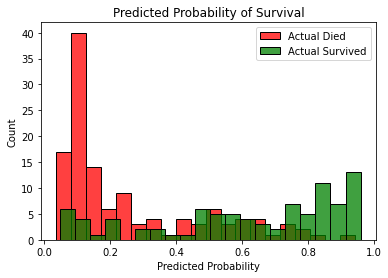

You might see “10 passengers had a predicted survival probability between 0.8 and 0.9


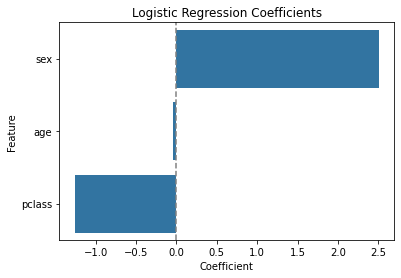

Each coefficient in logistic regression shows how much that feature affects the odds of the outcome — in this case, survival.
It answers: “If this feature increases by 1 unit, how does the log-odds of survival change?
positive - Increases probability of survival
Negative - Decreases probability of survival
Log Loss: 0.492129652773604
When a model predicts high probabilities for the correct class, log loss is lower.
If the model is very confident but wrong, the log loss is very high. For example:
Predicted probability for a false class of 0.99 → log loss will penalize it a lot.


In [ ]:
# Binary logistic regression - response - 02 possible outcomes

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load dataset
titanic = sns.load_dataset('titanic')
df = titanic[['survived', 'sex', 'age', 'pclass']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

X = df[['sex', 'age', 'pclass']]
y = df['survived']
print(len(y))

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Classification report
print("Titanic Dataset - Classification Report")
print(classification_report(y_test, y_pred))

# --- Plot 1: Confusion Matrix ---
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print('Diagonal cells (TN and TP) are correct predictions')
print('Off-diagonal cells (FP and FN) are errors')
print('It gives a quick sense of how many passengers were misclassified and in what way')

# --- Plot 2: Probability Histogram ---
plt.figure(figsize=(6, 4))
sns.histplot(y_prob[y_test == 0], color='red', label='Actual Died', bins=20, stat='density')
sns.histplot(y_prob[y_test == 1], color='green', label='Actual Survived', bins=20, stat='density')
plt.title("Predicted Probability of Survival")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

print('Here you see something like “5% of the distribution is in the 0.8–0.9 range')

print('Red bars show the distribution of predicted survival probabilities for passengers who actually died')
print('Green bars show the same, but for passengers who actually survived')

print('We are not just counting how many — we are showing the shape of the model’s confidence, normalized to be on the same scale for both classes')

# --- Plot 3: Count ---
plt.figure(figsize=(6, 4))
sns.histplot(y_prob[y_test == 0], color='red', label='Actual Died', bins=20, stat='count')
sns.histplot(y_prob[y_test == 1], color='green', label='Actual Survived', bins=20, stat='count')
plt.title("Predicted Probability of Survival")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

print('You might see “10 passengers had a predicted survival probability between 0.8 and 0.9')




# --- Plot 4: Feature Coefficients ---
coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})


plt.figure(figsize=(6, 4))
sns.barplot(x='Coefficient', y='Feature', data=coeffs)
plt.title("Logistic Regression Coefficients")
plt.axvline(0, color='gray', linestyle='--')
plt.show()


print('Each coefficient in logistic regression shows how much that feature affects the odds of the outcome — in this case, survival.')
print('It answers: “If this feature increases by 1 unit, how does the log-odds of survival change?')


print('positive - Increases probability of survival')
print('Negative - Decreases probability of survival')






from sklearn.metrics import log_loss
print(f"Log Loss: {log_loss(y_test, y_prob)}")


print('When a model predicts high probabilities for the correct class, log loss is lower.')
print('If the model is very confident but wrong, the log loss is very high. For example:')
print('Predicted probability for a false class of 0.99 → log loss will penalize it a lot.')

In [ ]:
print('Features', X.columns)
print ( 'Coefficents', model.coef_[0])


Features Index(['sex', 'age', 'pclass'], dtype='object')
Coefficents [ 2.50750991 -0.04062882 -1.26015419]


## sex (+2.5): Being female (1) instead of male (0) increases log-odds of survival significantly. Huge positive effect.
## age (-0.03): As age increases by 1 year, the log-odds of survival go down slightly.
## pclass (-1.2): Higher class (1st class) has better survival. So moving from 1st to 3rd class decreases chance of survival.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[39  4]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



/opt/anaconda3/envs/myenv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


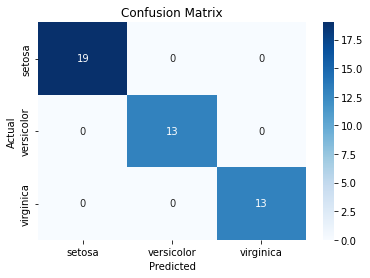


Logistic Regression Coefficients (One-vs-Rest):
            sepal_length  sepal_width  petal_length  petal_width
setosa         -0.980389     1.051428     -1.747783    -1.604326
versicolor      0.488076    -0.363353     -0.299712    -0.676174
virginica       0.492313    -0.688074      2.047495     2.280500


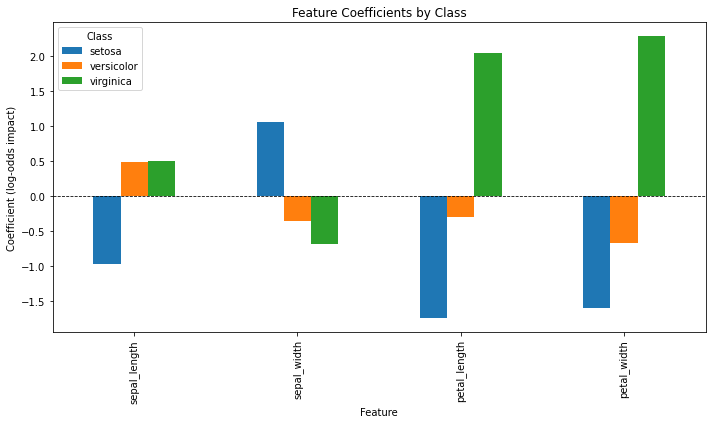

In [ ]:
# another known example
# multinomial logistic regression - three or more categories

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Load iris dataset
iris = sns.load_dataset("iris")
X = iris.drop("species", axis=1)
y = iris["species"]

# Standardize features for better coefficient comparability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train logistic regression (multi-class with softmax)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Coefficients Table
coef_df = pd.DataFrame(model.coef_, columns=X.columns, index=model.classes_)
print("\nLogistic Regression Coefficients (One-vs-Rest):")
print(coef_df)

# Plot Coefficients
coef_df.T.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Coefficients by Class")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.ylabel("Coefficient (log-odds impact)")
plt.xlabel("Feature")
plt.legend(title="Class")
plt.tight_layout()
plt.show()


Each class has its own logistic regression equation — the model compares all and picks the one with the highest score (probability). The coefficients show how features push the decision in favor of one class or another

In [ ]:
# ordinary logistic regression  -  More than two ordered classes
#(e.g., satisfaction: low < medium < high)

#For ranking-type predictions

import pandas as pd
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Simulated ordinal data
df = pd.DataFrame({
    'score': [1, 2, 3, 1, 2, 3, 1, 2, 3],
    'age': [23, 45, 35, 22, 48, 33, 25, 39, 31],
    'income': [30, 50, 40, 28, 52, 41, 33, 47, 38]
})

# Fit ordinal logistic regression
mod = OrderedModel(df['score'],
                   df[['age', 'income']],
                   distr='logit')
res = mod.fit(method='bfgs', disp=False)
print(res.summary())


print('see the coefficients')

                             OrderedModel Results                             
Dep. Variable:                  score   Log-Likelihood:                -8.8137
Model:                   OrderedModel   AIC:                             25.63
Method:            Maximum Likelihood   BIC:                             26.42
Date:                Sat, 03 May 2025                                         
Time:                        20:16:25                                         
No. Observations:                   9                                         
Df Residuals:                       5                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
age           -0.2086      0.485     -0.430      0.667      -1.160       0.743
income         0.3342      0.537      0.622      0.5

In [ ]:
# some more examples for you guys to go through

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data  # Features
y = data.target  # Target
print(X,y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=10000)
logistic_model.fit(X_train, y_train)

# Predict on test data
y_pred = logistic_model.predict(X_test)

# Evaluate the model
print("\nLogistic Regression on Breast Cancer Dataset:")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

from sklearn.metrics import log_loss

# Predict probabilities (not just labels)
y_pred_prob = logistic_model.predict_proba(X_test)
# print('log loss',y_pred_prob)
print(f"Log Loss: {log_loss(y_test, y_pred_prob)}")


[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Load the Iris dataset
data = load_iris()
X = data.data  # Features
print(X)
y = data.target  # Target
print(y)

# Select two classes for binary classification (e.g., classes 0 and 1) This dataset has three classes so doing this step
X = X[y != 2]#Filters the feature matrix X to include only rows corresponding to classes 0 and 1.
y = y[y != 2]#Filters the feature matrix yto include only rows corresponding to classes 0 and 1.

# # Select the first two features for 2D visualization
# X = X[:, :2]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Logistic Regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

# Predict on test data
y_pred = logistic_model.predict(X_test)

# Evaluate the model
print("\nLogistic Regression on Iris Dataset:")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
from sklearn.metrics import log_loss

# Predict probabilities (not just labels)
y_pred_prob = logistic_model.predict_proba(X_test)
# print('log loss',y_pred_prob)
print(f"Log Loss: {log_loss(y_test, y_pred_prob)}")


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [ ]:
#Social_Network_Ads.csv
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score

# Importing the dataset
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

# dataset:
#  This is the pandas DataFrame containing the dataset.
# .iloc[]:
#   Index-based selection: .iloc[] is used to select rows and columns in the DataFrame by their integer index positions (starting from 0).
# [:, [2, 3]]:
#   The colon (:) indicates selection of all rows.
#  [2, 3] indicates selection of the columns at index positions 2 and 3 (zero-based indexing).
# .values:
#   Converts the resulting DataFrame or Series into a NumPy array. The result is a 2D array where:
#   Rows correspond to the rows of the DataFrame.
#   Columns correspond to the specified column indices.



# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Standardize features by removing the mean and scaling to unit variance.
# The standard score of a sample x is calculated as:
# z = (x - u) / s
# where u is the mean of the training samples or zero if with_mean=False,
# and s is the standard deviation of the training samples or one if with_std=False.



# Fitting Logistic Regression to the Training set
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100

[[65  3]
 [ 8 24]]
0.89


In [ ]:
#  logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate binary classification data
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize binary logistic regression
model = LogisticRegression()

# Fit the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 0.855


In [ ]:
# Multinomial Logistic Regression (Multiclass Logistic Regression)
#Used for classification problems with more than two categories

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset with fewer clusters per class
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_classes=3,
    n_clusters_per_class=1,  # Reduce the number of clusters per class
    n_informative=3,         # Increase the number of informative features
    random_state=42
)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize multinomial logistic regression
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')

# Fit the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 0.87


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


(1797, 64)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       0.95      0.95      0.95        59
           2       0.98      1.00      0.99        55
           3       0.97      0.96      0.96        68
           4       0.97      0.98      0.98        66
           5       0.96      0.90      0.93        52
           6       1.00      1.00      1.00        54
           7       0.98      0.95      0.97        62
           8       0.89      0.98      0.93        51
           9       0.95      0.94      0.94        64

    accuracy                           0.97       594
   macro avg       0.97      0.97      0.97       594
weighted avg       0.97      0.97      0.97       594

[[63  0  0  0  0  0  0  0  0  0]
 [ 0 56  0  0  1  0  0  0  2  0]
 [ 0  0 55  0  0  0  0  0  0  0]
 [ 0  0  0 65  0  0  0  1  2  0]
 [ 0  1  0  0 65  0  0  0  0  0]
 [ 0  1  1  1  0 47  0  0  0  2]
 [ 0  0  0  0  0  0 54  0  0  0]

/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 640x480 with 0 Axes>

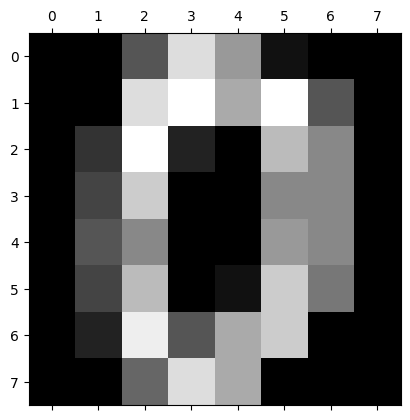

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.datasets import load_digits

digits = load_digits()
print(digits.data.shape)

import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits.images[0])

x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.33, random_state=1)
logmodel = LogisticRegression()
logmodel.fit(x_train, y_train)

predictions = logmodel.predict(x_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))
print(accuracy_score(y_test, predictions))

In [ ]:
# ordinary logistic regression
# you need to install mord
import mord
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create synthetic data: Features (study hours, number of assignments)
X = np.array([[5, 1], [6, 2], [7, 3], [4, 4], [8, 1], [9, 2], [3, 3], [2, 4], [6, 5], [7, 4]])

# Target variable (ordinal: 1=Very Poor, 2=Poor, 3=Average, 4=Good, 5=Excellent)
y = np.array([1, 2, 3, 3, 4, 4, 2, 1, 5, 4])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Ordinal Logistic Regression (using mord.LogisticAT)
model = mord.LogisticAT()

# Fit the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Display predictions
print(f"Predictions: {y_pred}")


Accuracy: 0.0
Predictions: [4 3]
